In [ ]:
# ============================================================
# 1) Install dependencies
# ============================================================
!pip install -q aeon torch scikit-learn matplotlib numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 41.9 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 2) Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from aeon.datasets import load_classification
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

In [ ]:
# ============================================================
# 3) Global config
# ============================================================
CONFIG = {
    "target_length": 150,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "hidden_dim": 64,
    "num_classes": 2,
    "lr": 1e-3,
    "batch_size": 16,
    "epochs": 30,
    "ewc_lambda": 200.0,
    "lwf_alpha": 1.0,
    "lwf_temperature": 2.0,
    "replay_per_class": 100,
    "tsfd_alpha_logits": 1.0,
    "tsfd_alpha_features": 0.5,
    "tsfd_temperature": 2.0,
    "proto_memory_per_class": 20,
    "proto_alpha": 0.5,
}

# 3-task sequences
SEQUENCES = [
    ["GunPoint", "ItalyPowerDemand", "SonyAIBORobotSurface1"],
    ["GunPoint", "SonyAIBORobotSurface1", "SonyAIBORobotSurface2"],
]

SEEDS = [0, 1, 2, 3, 4]

device = torch.device(CONFIG["device"])
print("Using device:", device)

Using device: cpu


In [ ]:
# ============================================================
# 4) Utilities
# ============================================================
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def resize_1d_series(x, target_length):
    old_idx = np.linspace(0, 1, len(x))
    new_idx = np.linspace(0, 1, target_length)
    return np.interp(new_idx, old_idx, x).astype(np.float32)

def make_loader(X, y, batch_size=16, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def accuracy(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            targets.extend(yb.cpu().numpy())
    return accuracy_score(targets, preds)

In [ ]:
# ============================================================
# 5) Task abstraction
# ============================================================
@dataclass
class TimeSeriesTask:
    name: str
    X_train: np.ndarray
    y_train: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray

class AeonTaskLoader:
    def __init__(self, target_length=150, only_first_channel=True):
        self.target_length = target_length
        self.only_first_channel = only_first_channel

    def load_task(self, dataset_name):
        X_train, y_train = load_classification(dataset_name, split="train")
        X_test, y_test = load_classification(dataset_name, split="test")

        if X_train.ndim == 3:
            if self.only_first_channel:
                X_train = X_train[:, 0, :]
                X_test = X_test[:, 0, :]
            else:
                raise ValueError("Multivariate handling not implemented yet.")
        elif X_train.ndim != 2:
            raise ValueError(f"Unexpected shape for {dataset_name}: {X_train.shape}")

        X_train = np.array([resize_1d_series(x, self.target_length) for x in X_train], dtype=np.float32)
        X_test = np.array([resize_1d_series(x, self.target_length) for x in X_test], dtype=np.float32)

        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)

        n_classes = len(np.unique(y_train))
        if n_classes != 2:
            raise ValueError(f"{dataset_name} is not binary. Found {n_classes} classes.")

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train).astype(np.float32)
        X_test = scaler.transform(X_test).astype(np.float32)

        return TimeSeriesTask(
            name=dataset_name,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test
        )

    def load_sequence(self, dataset_names):
        return [self.load_task(name) for name in dataset_names]

In [ ]:
# ============================================================
# 6) Models
# ============================================================
class FeatureMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def extract_features(self, x):
        return self.relu(self.fc1(x))

    def forward(self, x):
        feats = self.extract_features(x)
        logits = self.fc2(feats)
        return logits

In [ ]:
# ============================================================
# 7) Base continual learning strategy
# ============================================================
class BaseStrategy:
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.ce_loss = nn.CrossEntropyLoss()

    def train_epoch(self, loader, extra_loss_fn=None):
        self.model.train()
        for xb, yb in loader:
            xb, yb = xb.to(self.device), yb.to(self.device)

            self.optimizer.zero_grad()
            logits = self.model(xb)
            loss = self.ce_loss(logits, yb)

            if extra_loss_fn is not None:
                extra = extra_loss_fn(xb, yb, logits)
                if isinstance(extra, (int, float)):
                    extra = torch.tensor(extra, dtype=torch.float32, device=self.device)
                loss = loss + extra

            loss.backward()
            self.optimizer.step()

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
        for _ in range(self.epochs):
            self.train_epoch(loader)

    def evaluate_task(self, task):
        loader = make_loader(task.X_test, task.y_test, batch_size=self.batch_size, shuffle=False)
        return accuracy(self.model, loader, self.device)

In [ ]:
# ============================================================
# 8) Baseline strategy
# ============================================================
class BaselineStrategy(BaseStrategy):
    pass

In [ ]:
# ============================================================
# 9) EWC strategy
# ============================================================
class EWCStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, ewc_lambda=200.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.ewc_lambda = ewc_lambda
        self.fisher = None
        self.old_params = None

    def compute_fisher(self, task):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
        fisher = {n: torch.zeros_like(p) for n, p in self.model.named_parameters()}

        self.model.eval()
        for xb, yb in loader:
            xb, yb = xb.to(self.device), yb.to(self.device)
            self.model.zero_grad()
            logits = self.model(xb)
            loss = self.ce_loss(logits, yb)
            loss.backward()

            for n, p in self.model.named_parameters():
                if p.grad is not None:
                    fisher[n] += p.grad.detach() ** 2

        for n in fisher:
            fisher[n] /= len(loader)

        return fisher

    def save_old_params(self):
        self.old_params = {n: p.detach().clone() for n, p in self.model.named_parameters()}

    def ewc_penalty(self):
        if self.fisher is None or self.old_params is None:
            return torch.tensor(0.0, device=self.device)

        penalty = torch.tensor(0.0, device=self.device)
        for n, p in self.model.named_parameters():
            penalty += (self.fisher[n] * (p - self.old_params[n]) ** 2).sum()
        return 0.5 * self.ewc_lambda * penalty

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.ewc_penalty()

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.fisher = self.compute_fisher(task)
        self.save_old_params()

In [ ]:
# ============================================================
# 10) LwF strategy
# ============================================================
class LwFStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, alpha=1.0, temperature=2.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.alpha = alpha
        self.temperature = temperature
        self.teacher = None
        self.kl = nn.KLDivLoss(reduction="batchmean")

    def distillation_loss(self, xb, logits):
        if self.teacher is None:
            return torch.tensor(0.0, device=self.device)

        with torch.no_grad():
            teacher_logits = self.teacher(xb)

        student_log_probs = torch.log_softmax(logits / self.temperature, dim=1)
        teacher_probs = torch.softmax(teacher_logits / self.temperature, dim=1)
        return self.alpha * self.kl(student_log_probs, teacher_probs) * (self.temperature ** 2)

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.distillation_loss(xb, logits)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.teacher = deepcopy(self.model).to(self.device)
        self.teacher.eval()

In [ ]:
# ============================================================
# 11) Replay strategy
# ============================================================
class ReplayStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, replay_per_class=100):
        super().__init__(model, device, lr, batch_size, epochs)
        self.replay_per_class = replay_per_class
        self.replay_stats = None

    def fit_class_gaussians(self, X, y):
        stats = {}
        for c in np.unique(y):
            Xc = X[y == c]
            mean = Xc.mean(axis=0)
            var = Xc.var(axis=0) + 1e-4
            stats[c] = (mean, var)
        return stats

    def sample_replay(self):
        Xs, ys = [], []
        for c, (mean, var) in self.replay_stats.items():
            samples = np.random.randn(self.replay_per_class, len(mean)) * np.sqrt(var) + mean
            Xs.append(samples.astype(np.float32))
            ys.append(np.full(self.replay_per_class, c))
        return np.vstack(Xs), np.concatenate(ys)

    def fit_task(self, task, task_id=None):
        if task_id == 0:
            loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)
            self.replay_stats = self.fit_class_gaussians(task.X_train, task.y_train)
        else:
            X_replay, y_replay = self.sample_replay()
            X_mix = np.vstack([task.X_train, X_replay]).astype(np.float32)
            y_mix = np.concatenate([task.y_train, y_replay])

            loader = make_loader(X_mix, y_mix, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)

            self.replay_stats = self.fit_class_gaussians(X_mix, y_mix)

In [ ]:
# ============================================================
# 12) TS-FeatureDistill strategy
# ============================================================
class TSFeatureDistillStrategy(BaseStrategy):
    def __init__(
        self,
        model,
        device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        alpha_logits=1.0,
        alpha_features=1.0,
        temperature=2.0,
    ):
        super().__init__(model, device, lr, batch_size, epochs)
        self.alpha_logits = alpha_logits
        self.alpha_features = alpha_features
        self.temperature = temperature
        self.teacher = None
        self.kl = nn.KLDivLoss(reduction="batchmean")
        self.mse = nn.MSELoss()

    def distill_loss(self, xb, logits):
        if self.teacher is None:
            return torch.tensor(0.0, device=self.device)

        with torch.no_grad():
            teacher_logits = self.teacher(xb)
            teacher_feats = self.teacher.extract_features(xb)

        student_log_probs = torch.log_softmax(logits / self.temperature, dim=1)
        teacher_probs = torch.softmax(teacher_logits / self.temperature, dim=1)
        logit_loss = self.kl(student_log_probs, teacher_probs) * (self.temperature ** 2)

        student_feats = self.model.extract_features(xb)
        feat_loss = self.mse(student_feats, teacher_feats)

        return self.alpha_logits * logit_loss + self.alpha_features * feat_loss

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.distill_loss(xb, logits)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.teacher = deepcopy(self.model).to(self.device)
        self.teacher.eval()

In [ ]:
# ============================================================
# 13) TS-ProtoReplay strategy
# ============================================================
class TSProtoReplayStrategy(BaseStrategy):
    def __init__(
        self,
        model,
        device,
        lr=1e-3,
        batch_size=16,
        epochs=30,
        memory_per_class=20,
        alpha_proto=1.0,
    ):
        super().__init__(model, device, lr, batch_size, epochs)
        self.memory_per_class = memory_per_class
        self.alpha_proto = alpha_proto
        self.memory_X = []
        self.memory_y = []
        self.prototypes = {}
        self.mse = nn.MSELoss()

    def update_memory(self, X, y):
        mem_X, mem_y = [], []
        classes = np.unique(y)

        for c in classes:
            Xc = X[y == c]
            n = min(self.memory_per_class, len(Xc))
            idx = np.random.choice(len(Xc), size=n, replace=False)
            mem_X.append(Xc[idx])
            mem_y.append(np.full(n, c))

        mem_X = np.vstack(mem_X).astype(np.float32)
        mem_y = np.concatenate(mem_y)

        self.memory_X.append(mem_X)
        self.memory_y.append(mem_y)

    def get_memory(self):
        if len(self.memory_X) == 0:
            return None, None
        X_mem = np.vstack(self.memory_X).astype(np.float32)
        y_mem = np.concatenate(self.memory_y)
        return X_mem, y_mem

    def update_prototypes(self):
        X_mem, y_mem = self.get_memory()
        if X_mem is None:
            return

        self.model.eval()
        X_t = torch.tensor(X_mem, dtype=torch.float32).to(self.device)
        y_t = torch.tensor(y_mem, dtype=torch.long).to(self.device)

        with torch.no_grad():
            feats = self.model.extract_features(X_t)

        self.prototypes = {}
        for c in torch.unique(y_t):
            mask = y_t == c
            proto = feats[mask].mean(dim=0)
            self.prototypes[int(c.item())] = proto.detach().clone()

    def prototype_loss(self, xb, yb):
        if len(self.prototypes) == 0:
            return torch.tensor(0.0, device=self.device)

        feats = self.model.extract_features(xb)
        loss = torch.tensor(0.0, device=self.device)
        count = 0

        for c, proto in self.prototypes.items():
            mask = (yb == c)
            if mask.sum() > 0:
                loss += self.mse(feats[mask].mean(dim=0), proto.to(self.device))
                count += 1

        if count == 0:
            return torch.tensor(0.0, device=self.device)
        return self.alpha_proto * loss / count

    def fit_task(self, task, task_id=None):
        if task_id == 0:
            loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)

            self.update_memory(task.X_train, task.y_train)
            self.update_prototypes()
        else:
            X_mem, y_mem = self.get_memory()

            if X_mem is not None:
                X_mix = np.vstack([task.X_train, X_mem]).astype(np.float32)
                y_mix = np.concatenate([task.y_train, y_mem])
            else:
                X_mix, y_mix = task.X_train, task.y_train

            loader = make_loader(X_mix, y_mix, batch_size=self.batch_size, shuffle=True)

            def extra_loss_fn(xb, yb, logits):
                return self.prototype_loss(xb, yb)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

            self.update_memory(task.X_train, task.y_train)
            self.update_prototypes()

In [ ]:
# ============================================================
# 14) Metrics
# ============================================================
def final_average_accuracy(acc_matrix):
    """
    Mean accuracy on all seen tasks after the final task.
    """
    last_row = acc_matrix[-1]
    valid = last_row[last_row > 0]
    return valid.mean() if len(valid) > 0 else 0.0

def final_forgetting(acc_matrix):
    """
    Average forgetting over all tasks except the last one:
    max previous accuracy on task t - final accuracy on task t
    """
    n_tasks = acc_matrix.shape[1]
    forgetting = []

    for t in range(n_tasks - 1):
        best_before = np.max(acc_matrix[:, t])
        final_acc = acc_matrix[-1, t]
        forgetting.append(best_before - final_acc)

    return np.mean(forgetting) if len(forgetting) > 0 else 0.0

def per_task_final_accuracy(acc_matrix):
    """
    Final accuracy for each task after learning all tasks.
    """
    return acc_matrix[-1, :]

def backward_transfer(acc_matrix):
    """
    Simple BWT:
    average over tasks except last of (final_acc - acc_when_task_was_learned)
    Negative values mean forgetting.
    """
    n_tasks = acc_matrix.shape[0]
    bwt_vals = []

    for t in range(n_tasks - 1):
        final_acc = acc_matrix[-1, t]
        learned_acc = acc_matrix[t, t]
        bwt_vals.append(final_acc - learned_acc)

    return np.mean(bwt_vals) if len(bwt_vals) > 0 else 0.0

In [ ]:
# ============================================================
# 15) Experiment runner
# ============================================================
class ContinualLearningExperiment:
    def __init__(self, tasks, strategy_dict):
        self.tasks = tasks
        self.strategy_dict = strategy_dict
        self.results = {}

    def run(self):
        for name, strategy in self.strategy_dict.items():
            print(f"\nRunning strategy: {name}")
            n_tasks = len(self.tasks)
            acc_matrix = np.zeros((n_tasks, n_tasks))

            for task_id, task in enumerate(self.tasks):
                print(f"  Training on task {task_id+1}: {task.name}")
                strategy.fit_task(task, task_id=task_id)

                for eval_id in range(task_id + 1):
                    acc = strategy.evaluate_task(self.tasks[eval_id])
                    acc_matrix[task_id, eval_id] = acc
                    print(f"    Eval on task {eval_id+1} ({self.tasks[eval_id].name}): {acc:.4f}")

            self.results[name] = acc_matrix

        return self.results

    def summary(self):
        rows = []
        for name, acc_matrix in self.results.items():
            row = {
                "method": name,
                "final_avg_acc": final_average_accuracy(acc_matrix),
                "final_forgetting": final_forgetting(acc_matrix),
                "backward_transfer": backward_transfer(acc_matrix),
            }

            final_task_accs = per_task_final_accuracy(acc_matrix)
            for i, acc in enumerate(final_task_accs):
                row[f"final_task{i+1}_acc"] = acc

            rows.append(row)

        return pd.DataFrame(rows)

In [ ]:
# ============================================================
# 16) Strategy factory
# ============================================================
def make_strategies(input_dim, device):
    return {
        "Baseline": BaselineStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"]
        ),
        "EWC": EWCStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            ewc_lambda=CONFIG["ewc_lambda"]
        ),
        "LwF": LwFStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            alpha=CONFIG["lwf_alpha"],
            temperature=CONFIG["lwf_temperature"]
        ),
        "Replay": ReplayStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            replay_per_class=CONFIG["replay_per_class"]
        ),
        "TS-FeatureDistill": TSFeatureDistillStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            alpha_logits=CONFIG["tsfd_alpha_logits"],
            alpha_features=CONFIG["tsfd_alpha_features"],
            temperature=CONFIG["tsfd_temperature"]
        ),
        "TS-ProtoReplay": TSProtoReplayStrategy(
            model=FeatureMLP(input_dim=input_dim, hidden_dim=CONFIG["hidden_dim"], num_classes=CONFIG["num_classes"]),
            device=device,
            lr=CONFIG["lr"],
            batch_size=CONFIG["batch_size"],
            epochs=CONFIG["epochs"],
            memory_per_class=CONFIG["proto_memory_per_class"],
            alpha_proto=CONFIG["proto_alpha"]
        ),
    }

In [ ]:
# ============================================================
# 17) Sequence loading helper
# ============================================================
def load_task_sequence(task_names, target_length=150):
    loader = AeonTaskLoader(target_length=target_length)
    tasks = loader.load_sequence(task_names)
    return tasks

In [ ]:
# ============================================================
# 18) Single run: one sequence, one seed
# ============================================================
def run_one_sequence_one_seed(task_names, seed, device, target_length=150, verbose=True):
    set_seed(seed)

    tasks = load_task_sequence(task_names, target_length=target_length)
    input_dim = tasks[0].X_train.shape[1]

    strategies = make_strategies(input_dim, device)

    experiment = ContinualLearningExperiment(tasks, strategies)
    results = experiment.run()
    summary_df = experiment.summary()

    sequence_name = " -> ".join(task_names)
    summary_df["sequence"] = sequence_name
    summary_df["seed"] = seed

    matrices = {}
    for method, acc_matrix in results.items():
        matrices[method] = acc_matrix.copy()

    if verbose:
        print(f"\nFinished sequence: {sequence_name}, seed: {seed}")
        display(summary_df)

    return {
        "sequence": sequence_name,
        "seed": seed,
        "summary": summary_df,
        "matrices": matrices,
        "task_names": task_names,
    }

In [ ]:
# ============================================================
# 19) Full benchmark runner
# ============================================================
def run_benchmark(sequences, seeds, device, target_length=150, verbose=False):
    all_runs = []

    for seq in sequences:
        for seed in seeds:
            print("\n==============================")
            print(f"Running sequence {seq} with seed {seed}")
            print("==============================")

            run_data = run_one_sequence_one_seed(
                task_names=seq,
                seed=seed,
                device=device,
                target_length=target_length,
                verbose=verbose
            )
            all_runs.append(run_data)

    return all_runs

In [ ]:
# ============================================================
# 20) Aggregation helpers
# ============================================================
def aggregate_results(all_runs):
    all_summaries = []
    for run in all_runs:
        all_summaries.append(run["summary"])

    full_df = pd.concat(all_summaries, ignore_index=True)

    metric_cols = [
        "final_avg_acc",
        "final_forgetting",
        "backward_transfer",
    ]

    # add any final_taskX_acc columns dynamically
    final_task_cols = [c for c in full_df.columns if c.startswith("final_task") and c.endswith("_acc")]
    metric_cols.extend(final_task_cols)

    agg_dict = {}
    for col in metric_cols:
        agg_dict[f"{col}_mean"] = (col, "mean")
        agg_dict[f"{col}_std"] = (col, "std")

    agg_df = (
        full_df.groupby(["sequence", "method"])
        .agg(**agg_dict)
        .reset_index()
    )

    return full_df, agg_df

In [ ]:
# ============================================================
# 20b) Accuracy matrix aggregation for variable number of tasks
# ============================================================
def aggregate_accuracy_matrices(all_runs):
    rows = []

    for run in all_runs:
        sequence = run["sequence"]
        seed = run["seed"]

        for method, mat in run["matrices"].items():
            n_tasks = mat.shape[0]
            row = {
                "sequence": sequence,
                "seed": seed,
                "method": method,
                "n_tasks": n_tasks,
            }

            for i in range(n_tasks):
                for j in range(n_tasks):
                    row[f"acc_afterT{i+1}_onT{j+1}"] = mat[i, j]

            rows.append(row)

    mat_df = pd.DataFrame(rows)

    acc_cols = [c for c in mat_df.columns if c.startswith("acc_afterT")]
    agg_dict = {}
    for col in acc_cols:
        agg_dict[f"{col}_mean"] = (col, "mean")
        agg_dict[f"{col}_std"] = (col, "std")

    mat_agg = (
        mat_df.groupby(["sequence", "method", "n_tasks"])
        .agg(**agg_dict)
        .reset_index()
    )

    return mat_df, mat_agg

In [ ]:
# ============================================================
# 21) Plotting helpers
# ============================================================
def plot_sequence_results(agg_df, metric="final_avg_acc_mean"):
    sequences = agg_df["sequence"].unique()

    for seq in sequences:
        sub = agg_df[agg_df["sequence"] == seq].copy()

        if metric == "final_avg_acc_mean":
            y = sub["final_avg_acc_mean"].values
            yerr = sub["final_avg_acc_std"].fillna(0).values
            title = f"Final Average Accuracy: {seq}"
            ylabel = "Final Average Accuracy"
        elif metric == "final_forgetting_mean":
            y = sub["final_forgetting_mean"].values
            yerr = sub["final_forgetting_std"].fillna(0).values
            title = f"Final Forgetting: {seq}"
            ylabel = "Final Forgetting"
        elif metric == "backward_transfer_mean":
            y = sub["backward_transfer_mean"].values
            yerr = sub["backward_transfer_std"].fillna(0).values
            title = f"Backward Transfer: {seq}"
            ylabel = "Backward Transfer"
        else:
            raise ValueError("Unsupported metric")

        plt.figure(figsize=(10, 4))
        plt.bar(sub["method"], y, yerr=yerr, capsize=4)
        plt.xticks(rotation=45)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.show()

def plot_mean_accuracy_matrices(mat_agg):
    for _, row in mat_agg.iterrows():
        sequence = row["sequence"]
        method = row["method"]
        n_tasks = int(row["n_tasks"])

        mat = np.zeros((n_tasks, n_tasks))
        for i in range(n_tasks):
            for j in range(n_tasks):
                key = f"acc_afterT{i+1}_onT{j+1}_mean"
                if key in row:
                    mat[i, j] = row[key]

        plt.figure(figsize=(4 + n_tasks, 3 + n_tasks * 0.2))
        plt.imshow(mat, cmap="Blues", vmin=0, vmax=1)
        plt.colorbar(label="Accuracy")
        plt.xticks(range(n_tasks), [f"Task{j+1}" for j in range(n_tasks)])
        plt.yticks(range(n_tasks), [f"After T{i+1}" for i in range(n_tasks)])
        plt.title(f"{method}\n{sequence}")
        plt.tight_layout()
        plt.show()

def plot_final_task_accuracies(agg_df):
    sequences = agg_df["sequence"].unique()

    final_task_cols = [c for c in agg_df.columns if c.startswith("final_task") and c.endswith("_mean")]

    for seq in sequences:
        sub = agg_df[agg_df["sequence"] == seq].copy()
        plt.figure(figsize=(10, 5))

        x = np.arange(len(sub))
        width = 0.8 / max(1, len(final_task_cols))

        for k, col in enumerate(final_task_cols):
            std_col = col.replace("_mean", "_std")
            plt.bar(
                x + k * width,
                sub[col].values,
                width=width,
                yerr=sub[std_col].fillna(0).values if std_col in sub.columns else None,
                capsize=3,
                label=col.replace("_mean", "")
            )

        plt.xticks(x + width * (len(final_task_cols) - 1) / 2, sub["method"], rotation=45)
        plt.ylabel("Accuracy")
        plt.title(f"Final Per-Task Accuracy: {seq}")
        plt.legend()
        plt.show()

In [ ]:
# ============================================================
# 22) Run the full 3-task benchmark
# ============================================================
all_runs = run_benchmark(
    sequences=SEQUENCES,
    seeds=SEEDS,
    device=device,
    target_length=CONFIG["target_length"],
    verbose=False
)


Running sequence ['GunPoint', 'ItalyPowerDemand', 'SonyAIBORobotSurface1'] with seed 0


/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_8138/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/


Running strategy: Baseline
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8933
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.5533
    Eval on task 2 (ItalyPowerDemand): 0.9572
  Training on task 3: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.3800
    Eval on task 2 (ItalyPowerDemand): 0.6560
    Eval on task 3 (SonyAIBORobotSurface1): 0.8253

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8667
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.5600
    Eval on task 2 (ItalyPowerDemand): 0.9553
  Training on task 3: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.4333
    Eval on task 2 (ItalyPowerDemand): 0.6016
    Eval on task 3 (SonyAIBORobotSurface1): 0.8103

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8933
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.7600
    Eval on task 2 (ItalyPowerDemand):

/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_8138/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/


Running strategy: Baseline
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8667
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.5600
    Eval on task 2 (ItalyPowerDemand): 0.9534
  Training on task 3: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.4000
    Eval on task 2 (ItalyPowerDemand): 0.6599
    Eval on task 3 (SonyAIBORobotSurface1): 0.8519

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8800
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.5467
    Eval on task 2 (ItalyPowerDemand): 0.9495
  Training on task 3: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.4067
    Eval on task 2 (ItalyPowerDemand): 0.6754
    Eval on task 3 (SonyAIBORobotSurface1): 0.8453

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8733
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.7400
    Eval on task 2 (ItalyPowerDemand):

...

    Eval on task 1 (GunPoint): 0.8600
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.7867
    Eval on task 2 (SonyAIBORobotSurface1): 0.7188
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.6533
    Eval on task 2 (SonyAIBORobotSurface1): 0.6506
    Eval on task 3 (SonyAIBORobotSurface2): 0.7996

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8533
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.6733
    Eval on task 2 (SonyAIBORobotSurface1): 0.6972
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.6533
    Eval on task 2 (SonyAIBORobotSurface1): 0.6223
    Eval on task 3 (SonyAIBORobotSurface2): 0.7996

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8667
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8733
    Eval on task 2 (SonyAIBORobotSurface1): 0.5790
  Training 

/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_8138/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/

    Eval on task 1 (GunPoint): 0.8867
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8667
    Eval on task 2 (SonyAIBORobotSurface1): 0.7354
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.6867
    Eval on task 2 (SonyAIBORobotSurface1): 0.6689
    Eval on task 3 (SonyAIBORobotSurface2): 0.8122

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.9000
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8667
    Eval on task 2 (SonyAIBORobotSurface1): 0.7055
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.6867
    Eval on task 2 (SonyAIBORobotSurface1): 0.6339
    Eval on task 3 (SonyAIBORobotSurface2): 0.8080

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8667
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8933
    Eval on task 2 (SonyAIBORobotSurface1): 0.6456
  Training 

/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_8138/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/


Running strategy: Baseline
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.9000
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8867
    Eval on task 2 (SonyAIBORobotSurface1): 0.7255
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.7133
    Eval on task 2 (SonyAIBORobotSurface1): 0.6689
    Eval on task 3 (SonyAIBORobotSurface2): 0.8006

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8600
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8200
    Eval on task 2 (SonyAIBORobotSurface1): 0.7255
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.6400
    Eval on task 2 (SonyAIBORobotSurface1): 0.6622
    Eval on task 3 (SonyAIBORobotSurface2): 0.8048

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8733
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8800
   

In [ ]:
# ============================================================
# 23) Aggregate results
# ============================================================
full_df, agg_df = aggregate_results(all_runs)
mat_df, mat_agg = aggregate_accuracy_matrices(all_runs)

print("\n=== Per-run summary ===")
display(full_df)

print("\n=== Mean / Std summary ===")
display(agg_df)

print("\n=== Mean / Std matrix summary ===")
display(mat_agg)


=== Per-run summary ===


,method,final_avg_acc,final_forgetting,backward_transfer,final_task1_acc,final_task2_acc,final_task3_acc,sequence,seed
0,Baseline,0.620423,0.407298,-0.407298,0.380000,0.655977,0.825291,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
1,EWC,0.615068,0.393537,-0.393537,0.433333,0.601555,0.810316,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
2,LwF,0.701182,0.090000,-0.084655,0.713333,0.578231,0.811980,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
3,Replay,0.705340,0.208348,-0.208348,0.733333,0.658892,0.723794,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
4,TS-FeatureDistill,0.740662,0.083333,-0.021623,0.720000,0.701652,0.800333,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
5,TS-ProtoReplay,0.817279,0.055199,-0.055199,0.800000,0.893100,0.758735,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
6,Baseline,0.637259,0.380078,-0.380078,0.400000,0.659864,0.851913,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,1
7,EWC,0.642446,0.373693,-0.373693,0.406667,0.675413,0.845258,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,1
8,LwF,0.711528,0.053333,-0.040700,0.766667,0.602527,0.765391,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,1
9,Replay,0.693580,0.215909,-0.215909,0.733333,0.610301,0.737105,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,1



=== Mean / Std summary ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std,final_task2_acc_mean,final_task2_acc_std,final_task3_acc_mean,final_task3_acc_std
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,0.628327,0.010952,0.387885,0.014565,-0.387885,0.014565,0.389333,0.012111,0.668027,0.027406,0.827621,0.016539
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,0.630906,0.010353,0.377020,0.010313,-0.377020,0.010313,0.420000,0.026247,0.649757,0.031823,0.822962,0.021263
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,0.717029,0.010814,0.058111,0.018666,-0.049170,0.019900,0.760000,0.030912,0.590087,0.023759,0.800998,0.020968
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,0.719110,0.020941,0.184620,0.026224,-0.184620,0.026224,0.736000,0.007601,0.691545,0.062092,0.729784,0.009745
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,0.705960,0.034297,0.102000,0.014259,-0.053798,0.050406,0.660000,0.037118,0.669193,0.083711,0.788686,0.015159
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,0.828470,0.007933,0.047174,0.006456,-0.047174,0.006456,0.804000,0.010111,0.904373,0.011874,0.777038,0.010589
6,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,Baseline,0.716859,0.015017,0.133946,0.007933,-0.133946,0.007933,0.678667,0.028048,0.668552,0.020729,0.803358,0.005065
7,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,EWC,0.711392,0.017320,0.133783,0.009931,-0.133783,0.009931,0.665333,0.020763,0.664226,0.038186,0.804617,0.005719
8,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,LwF,0.670916,0.019544,0.032486,0.025877,-0.025819,0.027916,0.840000,0.042426,0.596672,0.029779,0.576076,0.033529
9,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,Replay,0.705177,0.013963,0.103090,0.018736,-0.103090,0.018736,0.766667,0.026667,0.601331,0.024301,0.747534,0.006743



=== Mean / Std matrix summary ===


,sequence,method,n_tasks,acc_afterT1_onT1_mean,acc_afterT1_onT1_std,acc_afterT1_onT2_mean,acc_afterT1_onT2_std,acc_afterT1_onT3_mean,acc_afterT1_onT3_std,acc_afterT2_onT1_mean,...,acc_afterT2_onT2_mean,acc_afterT2_onT2_std,acc_afterT2_onT3_mean,acc_afterT2_onT3_std,acc_afterT3_onT1_mean,acc_afterT3_onT1_std,acc_afterT3_onT2_mean,acc_afterT3_onT2_std,acc_afterT3_onT3_mean,acc_afterT3_onT3_std
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,3,0.881333,0.017256,0.0,0.0,0.0,0.0,0.554667,...,0.951798,0.003675,0.0,0.0,0.389333,0.012111,0.668027,0.027406,0.827621,0.016539
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,3,0.872000,0.018499,0.0,0.0,0.0,0.0,0.553333,...,0.951798,0.002439,0.0,0.0,0.420000,0.026247,0.649757,0.031823,0.822962,0.021263
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,3,0.874667,0.010954,0.0,0.0,0.0,0.0,0.746667,...,0.573761,0.010321,0.0,0.0,0.760000,0.030912,0.590087,0.023759,0.800998,0.020968
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,3,0.881333,0.014453,0.0,0.0,0.0,0.0,0.688000,...,0.915452,0.004810,0.0,0.0,0.736000,0.007601,0.691545,0.062092,0.729784,0.009745
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,3,0.864000,0.025647,0.0,0.0,0.0,0.0,0.664000,...,0.572789,0.004589,0.0,0.0,0.660000,0.037118,0.669193,0.083711,0.788686,0.015159
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,3,0.866667,0.009428,0.0,0.0,0.0,0.0,0.777333,...,0.936054,0.003597,0.0,0.0,0.804000,0.010111,0.904373,0.011874,0.777038,0.010589
6,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,Baseline,3,0.881333,0.017256,0.0,0.0,0.0,0.0,0.849333,...,0.733777,0.021567,0.0,0.0,0.678667,0.028048,0.668552,0.020729,0.803358,0.005065
7,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,EWC,3,0.872000,0.018499,0.0,0.0,0.0,0.0,0.788000,...,0.725125,0.025273,0.0,0.0,0.665333,0.020763,0.664226,0.038186,0.804617,0.005719
8,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,LwF,3,0.874667,0.010954,0.0,0.0,0.0,0.0,0.881333,...,0.613644,0.025190,0.0,0.0,0.840000,0.042426,0.596672,0.029779,0.576076,0.033529
9,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,Replay,3,0.881333,0.014453,0.0,0.0,0.0,0.0,0.798667,...,0.692845,0.013951,0.0,0.0,0.766667,0.026667,0.601331,0.024301,0.747534,0.006743


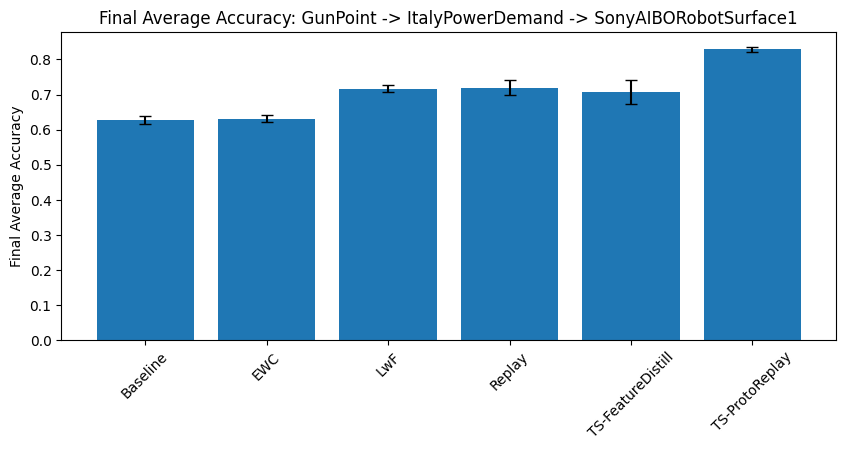

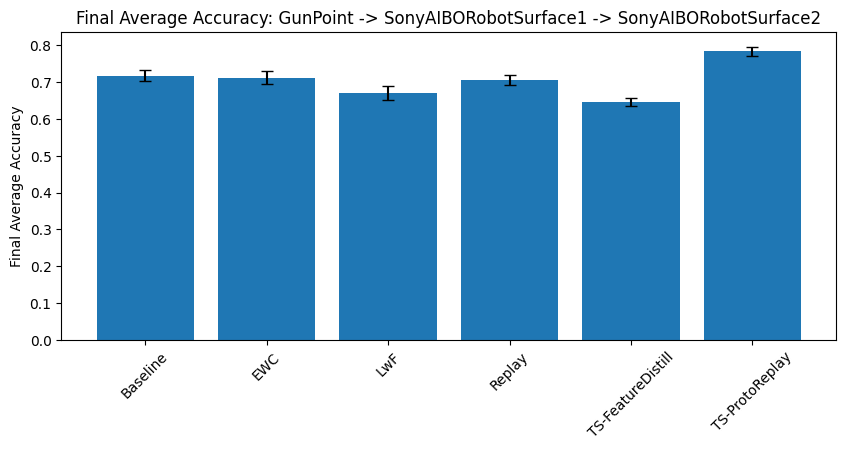

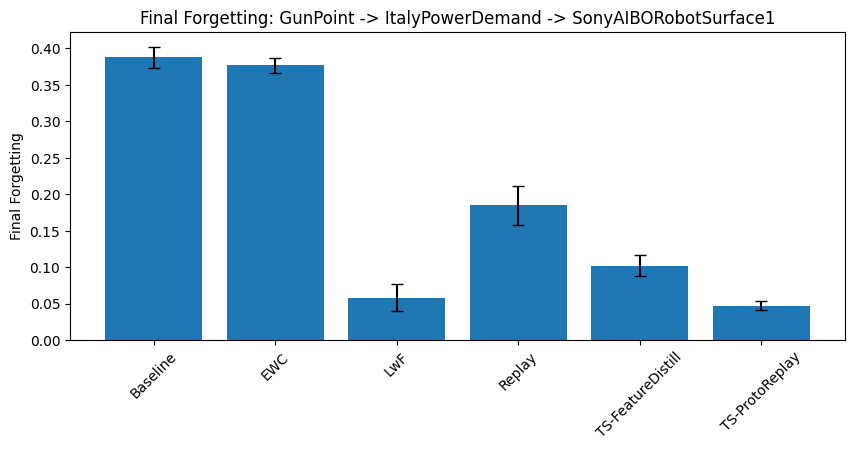

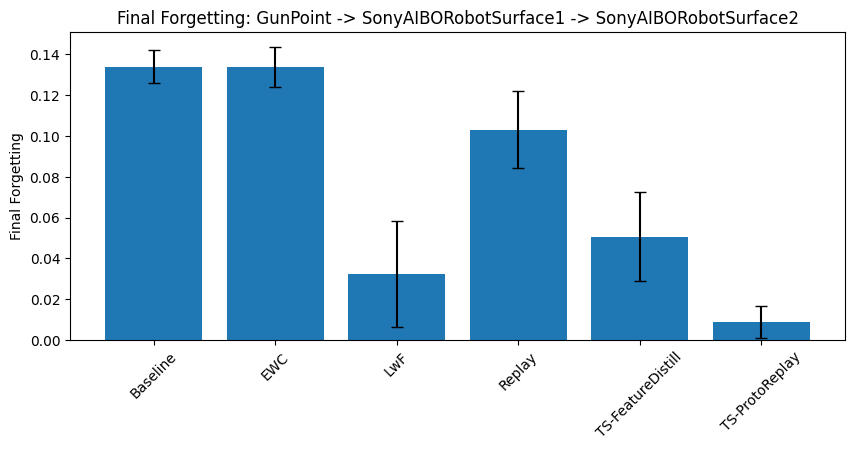

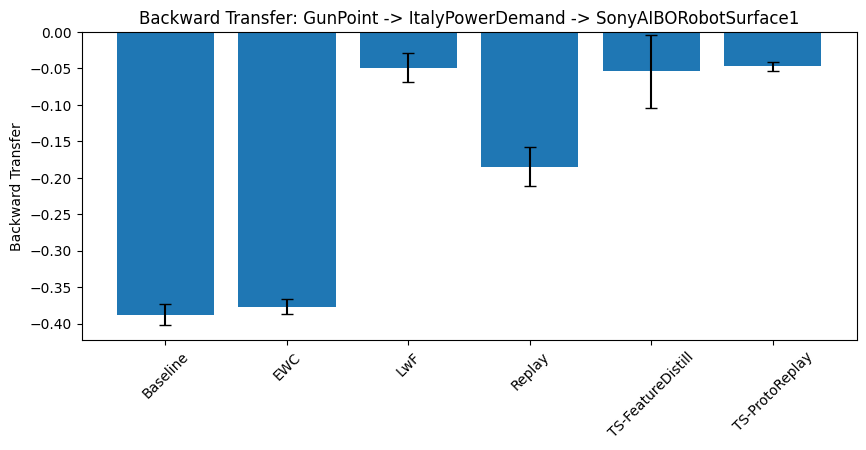

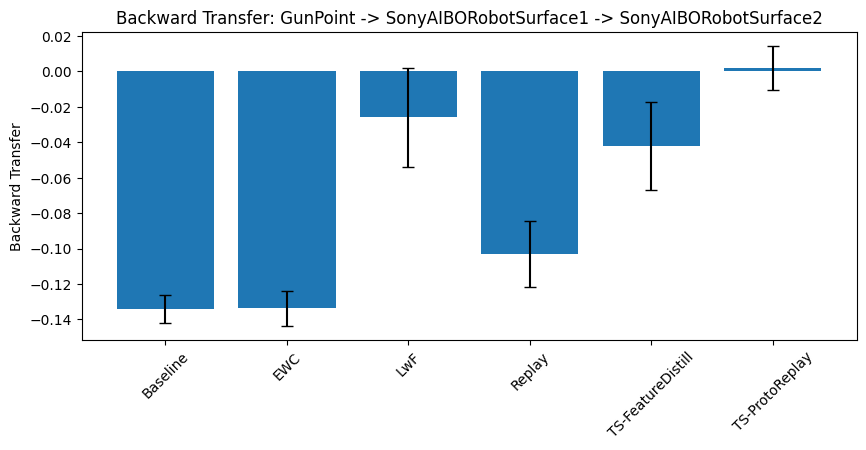

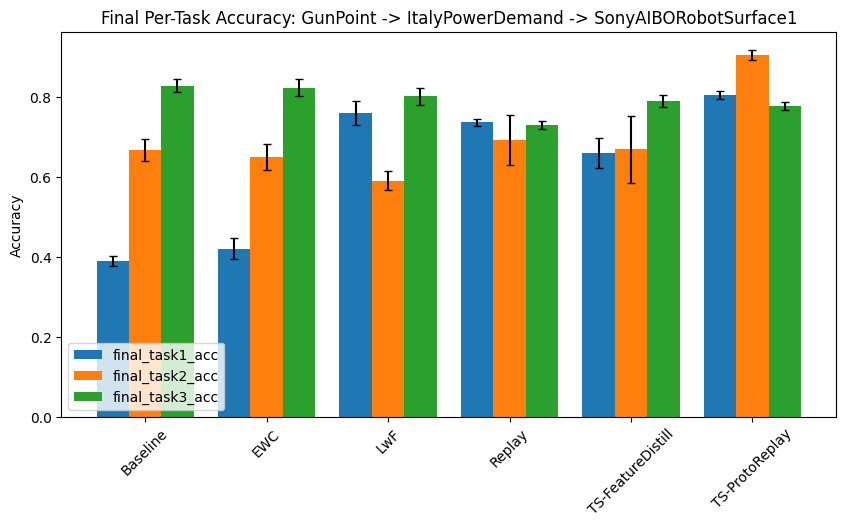

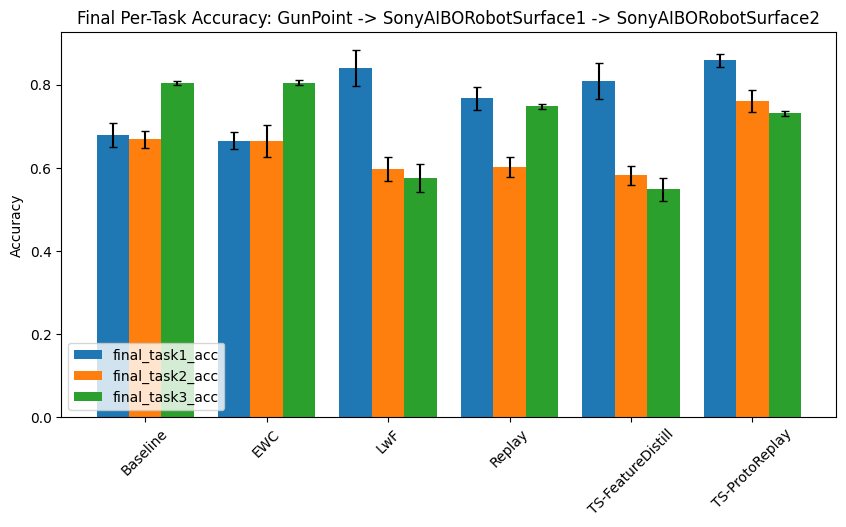

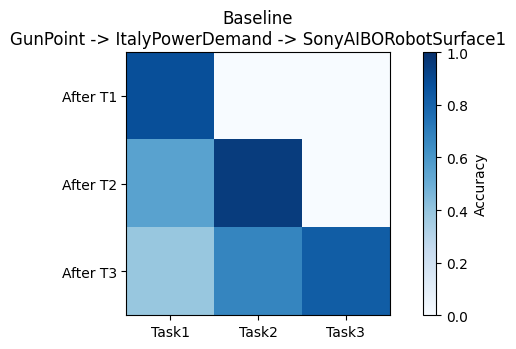

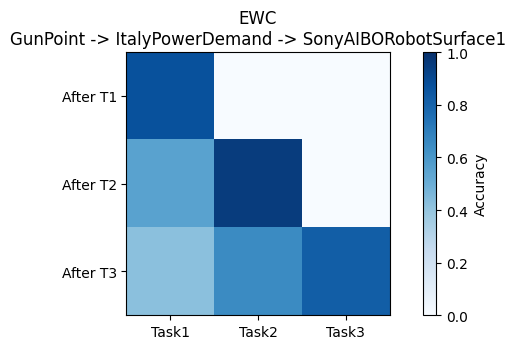

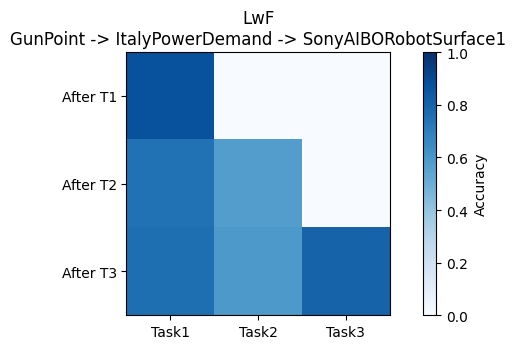

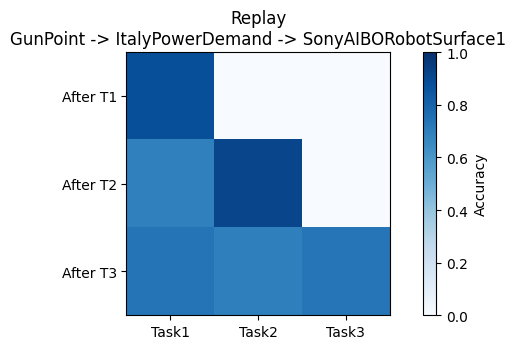

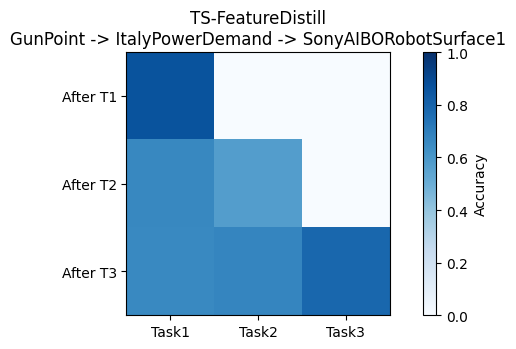

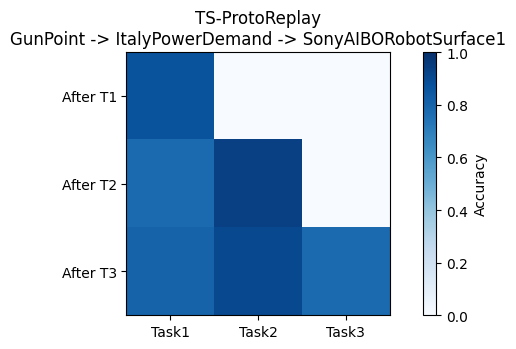

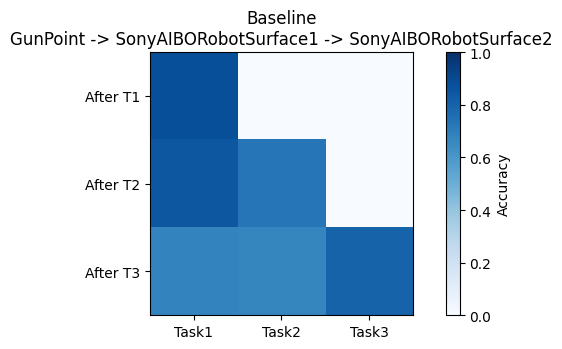

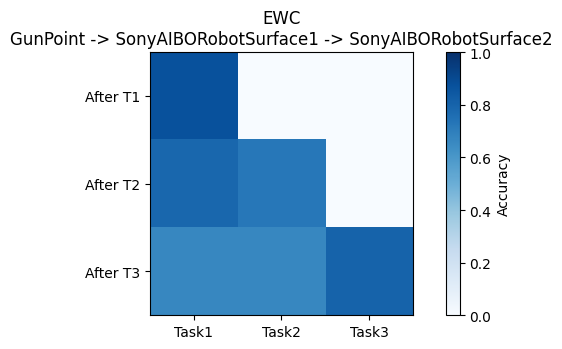

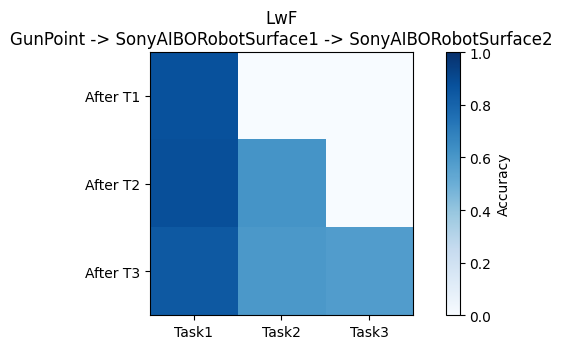

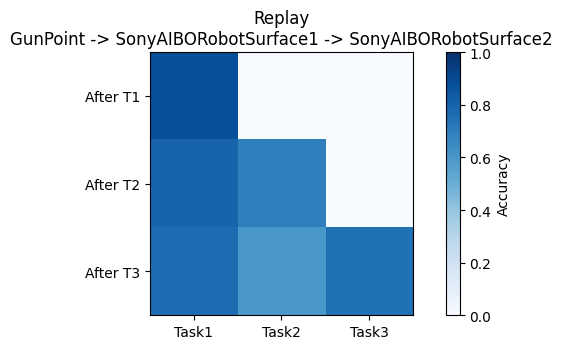

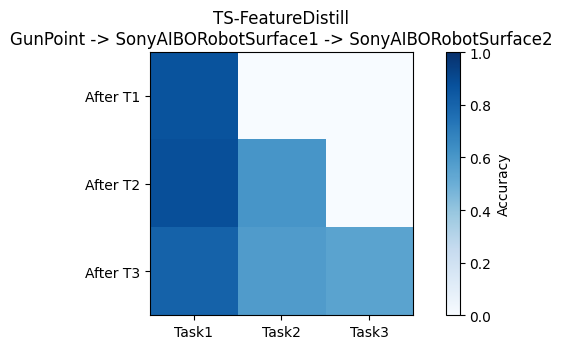

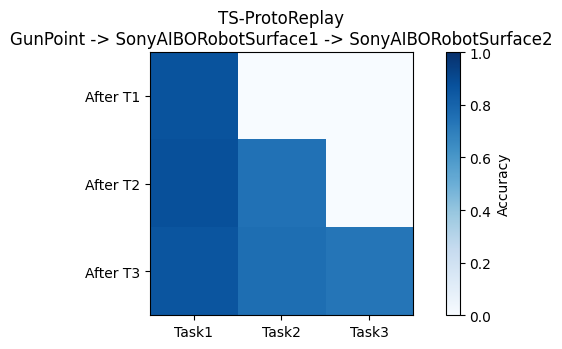

In [ ]:
# ============================================================
# 24) Plot results
# ============================================================
plot_sequence_results(agg_df, metric="final_avg_acc_mean")
plot_sequence_results(agg_df, metric="final_forgetting_mean")
plot_sequence_results(agg_df, metric="backward_transfer_mean")

plot_final_task_accuracies(agg_df)
plot_mean_accuracy_matrices(mat_agg)

In [ ]:
# ============================================================
# 25) Ranked views
# ============================================================
def rank_methods(agg_df, by="final_avg_acc_mean", ascending=False):
    return agg_df.sort_values(["sequence", by], ascending=[True, ascending]).copy()

print("\n=== Ranked by Final Average Accuracy ===")
display(rank_methods(agg_df, by="final_avg_acc_mean", ascending=False))

print("\n=== Ranked by Final Forgetting ===")
display(rank_methods(agg_df, by="final_forgetting_mean", ascending=True))

print("\n=== Ranked by Backward Transfer ===")
display(rank_methods(agg_df, by="backward_transfer_mean", ascending=False))


=== Ranked by Final Average Accuracy ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std,final_task2_acc_mean,final_task2_acc_std,final_task3_acc_mean,final_task3_acc_std
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,0.828470,0.007933,0.047174,0.006456,-0.047174,0.006456,0.804000,0.010111,0.904373,0.011874,0.777038,0.010589
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,0.719110,0.020941,0.184620,0.026224,-0.184620,0.026224,0.736000,0.007601,0.691545,0.062092,0.729784,0.009745
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,0.717029,0.010814,0.058111,0.018666,-0.049170,0.019900,0.760000,0.030912,0.590087,0.023759,0.800998,0.020968
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,0.705960,0.034297,0.102000,0.014259,-0.053798,0.050406,0.660000,0.037118,0.669193,0.083711,0.788686,0.015159
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,0.630906,0.010353,0.377020,0.010313,-0.377020,0.010313,0.420000,0.026247,0.649757,0.031823,0.822962,0.021263
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,0.628327,0.010952,0.387885,0.014565,-0.387885,0.014565,0.389333,0.012111,0.668027,0.027406,0.827621,0.016539
11,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,TS-ProtoReplay,0.783340,0.012633,0.008833,0.007628,0.001990,0.012346,0.858667,0.015202,0.760399,0.025480,0.730955,0.006101
6,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,Baseline,0.716859,0.015017,0.133946,0.007933,-0.133946,0.007933,0.678667,0.028048,0.668552,0.020729,0.803358,0.005065
7,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,EWC,0.711392,0.017320,0.133783,0.009931,-0.133783,0.009931,0.665333,0.020763,0.664226,0.038186,0.804617,0.005719
9,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,Replay,0.705177,0.013963,0.103090,0.018736,-0.103090,0.018736,0.766667,0.026667,0.601331,0.024301,0.747534,0.006743



=== Ranked by Final Forgetting ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std,final_task2_acc_mean,final_task2_acc_std,final_task3_acc_mean,final_task3_acc_std
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,0.828470,0.007933,0.047174,0.006456,-0.047174,0.006456,0.804000,0.010111,0.904373,0.011874,0.777038,0.010589
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,0.717029,0.010814,0.058111,0.018666,-0.049170,0.019900,0.760000,0.030912,0.590087,0.023759,0.800998,0.020968
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,0.705960,0.034297,0.102000,0.014259,-0.053798,0.050406,0.660000,0.037118,0.669193,0.083711,0.788686,0.015159
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,0.719110,0.020941,0.184620,0.026224,-0.184620,0.026224,0.736000,0.007601,0.691545,0.062092,0.729784,0.009745
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,0.630906,0.010353,0.377020,0.010313,-0.377020,0.010313,0.420000,0.026247,0.649757,0.031823,0.822962,0.021263
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,0.628327,0.010952,0.387885,0.014565,-0.387885,0.014565,0.389333,0.012111,0.668027,0.027406,0.827621,0.016539
11,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,TS-ProtoReplay,0.783340,0.012633,0.008833,0.007628,0.001990,0.012346,0.858667,0.015202,0.760399,0.025480,0.730955,0.006101
8,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,LwF,0.670916,0.019544,0.032486,0.025877,-0.025819,0.027916,0.840000,0.042426,0.596672,0.029779,0.576076,0.033529
10,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,TS-FeatureDistill,0.645703,0.011185,0.050643,0.021781,-0.041977,0.024843,0.808000,0.043563,0.581364,0.023134,0.547744,0.027151
9,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,Replay,0.705177,0.013963,0.103090,0.018736,-0.103090,0.018736,0.766667,0.026667,0.601331,0.024301,0.747534,0.006743



=== Ranked by Backward Transfer ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std,final_task2_acc_mean,final_task2_acc_std,final_task3_acc_mean,final_task3_acc_std
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,0.828470,0.007933,0.047174,0.006456,-0.047174,0.006456,0.804000,0.010111,0.904373,0.011874,0.777038,0.010589
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,0.717029,0.010814,0.058111,0.018666,-0.049170,0.019900,0.760000,0.030912,0.590087,0.023759,0.800998,0.020968
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,0.705960,0.034297,0.102000,0.014259,-0.053798,0.050406,0.660000,0.037118,0.669193,0.083711,0.788686,0.015159
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,0.719110,0.020941,0.184620,0.026224,-0.184620,0.026224,0.736000,0.007601,0.691545,0.062092,0.729784,0.009745
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,0.630906,0.010353,0.377020,0.010313,-0.377020,0.010313,0.420000,0.026247,0.649757,0.031823,0.822962,0.021263
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,0.628327,0.010952,0.387885,0.014565,-0.387885,0.014565,0.389333,0.012111,0.668027,0.027406,0.827621,0.016539
11,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,TS-ProtoReplay,0.783340,0.012633,0.008833,0.007628,0.001990,0.012346,0.858667,0.015202,0.760399,0.025480,0.730955,0.006101
8,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,LwF,0.670916,0.019544,0.032486,0.025877,-0.025819,0.027916,0.840000,0.042426,0.596672,0.029779,0.576076,0.033529
10,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,TS-FeatureDistill,0.645703,0.011185,0.050643,0.021781,-0.041977,0.024843,0.808000,0.043563,0.581364,0.023134,0.547744,0.027151
9,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,Replay,0.705177,0.013963,0.103090,0.018736,-0.103090,0.018736,0.766667,0.026667,0.601331,0.024301,0.747534,0.006743


In [ ]:
# ============================================================
# 27) Soft-voting ensemble
# ============================================================
class SoftVotingEnsemble:
    def __init__(self, strategies, device, include_methods=None):
        """
        strategies: dict of trained strategy objects
        include_methods: list of method names to include in ensemble
        """
        self.device = device

        if include_methods is None:
            self.strategies = strategies
        else:
            self.strategies = {
                name: strat for name, strat in strategies.items()
                if name in include_methods
            }

        if len(self.strategies) == 0:
            raise ValueError("No strategies selected for ensemble.")

        self.include_methods = list(self.strategies.keys())

    def predict_proba(self, X, batch_size=32):
        X_t = torch.tensor(X, dtype=torch.float32)
        loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=False)

        all_probs = []

        for strategy_name, strategy in self.strategies.items():
            strategy.model.eval()
            probs_list = []

            with torch.no_grad():
                for batch in loader:
                    xb = batch[0].to(self.device)
                    logits = strategy.model(xb)
                    probs = torch.softmax(logits, dim=1)
                    probs_list.append(probs.cpu().numpy())

            probs_model = np.vstack(probs_list)
            all_probs.append(probs_model)

        mean_probs = np.mean(all_probs, axis=0)
        return mean_probs

    def predict(self, X, batch_size=32):
        probs = self.predict_proba(X, batch_size=batch_size)
        return np.argmax(probs, axis=1)

    def evaluate_task(self, task, batch_size=32):
        y_pred = self.predict(task.X_test, batch_size=batch_size)
        return accuracy_score(task.y_test, y_pred)

In [ ]:
# ============================================================
# 28) Experiment runner with multiple ensemble variants
# ============================================================
class ContinualLearningExperiment:
    def __init__(self, tasks, strategy_dict):
        self.tasks = tasks
        self.strategy_dict = strategy_dict
        self.results = {}
        self.trained_strategies = {}

    def run(self):
        for name, strategy in self.strategy_dict.items():
            print(f"\nRunning strategy: {name}")
            n_tasks = len(self.tasks)
            acc_matrix = np.zeros((n_tasks, n_tasks))

            for task_id, task in enumerate(self.tasks):
                print(f"  Training on task {task_id+1}: {task.name}")
                strategy.fit_task(task, task_id=task_id)

                for eval_id in range(task_id + 1):
                    acc = strategy.evaluate_task(self.tasks[eval_id])
                    acc_matrix[task_id, eval_id] = acc
                    print(f"    Eval on task {eval_id+1} ({self.tasks[eval_id].name}): {acc:.4f}")

            self.results[name] = acc_matrix
            self.trained_strategies[name] = strategy

        return self.results

    def evaluate_named_ensemble(self, ensemble_name, include_methods):
        n_tasks = len(self.tasks)
        acc_matrix = np.zeros((n_tasks, n_tasks))

        ensemble = SoftVotingEnsemble(
            strategies=self.trained_strategies,
            device=list(self.trained_strategies.values())[0].device,
            include_methods=include_methods
        )

        print(f"\nRunning ensemble: {ensemble_name}")
        print(f"  Included methods: {ensemble.include_methods}")

        for eval_id, task in enumerate(self.tasks):
            acc = ensemble.evaluate_task(task)
            acc_matrix[-1, eval_id] = acc
            print(f"    Eval on task {eval_id+1} ({task.name}): {acc:.4f}")

        self.results[ensemble_name] = acc_matrix
        return acc_matrix

    def evaluate_default_ensembles(self):
        all_methods = list(self.trained_strategies.keys())

        cl_only_methods = [
            "EWC",
            "LwF",
            "Replay",
            "TS-FeatureDistill",
            "TS-ProtoReplay"
        ]

        cl_only_methods = [m for m in cl_only_methods if m in self.trained_strategies]

        self.evaluate_named_ensemble(
            ensemble_name="SoftVotingEnsemble-All",
            include_methods=all_methods
        )

        self.evaluate_named_ensemble(
            ensemble_name="SoftVotingEnsemble-CLOnly",
            include_methods=cl_only_methods
        )

    def summary(self):
        rows = []
        for name, acc_matrix in self.results.items():
            row = {
                "method": name,
                "final_avg_acc": final_average_accuracy(acc_matrix),
                "final_forgetting": final_forgetting(acc_matrix),
                "backward_transfer": backward_transfer(acc_matrix),
            }

            final_task_accs = per_task_final_accuracy(acc_matrix)
            for i, acc in enumerate(final_task_accs):
                row[f"final_task{i+1}_acc"] = acc

            rows.append(row)

        return pd.DataFrame(rows)

In [ ]:
# ============================================================
# 29) Single run: one sequence, one seed, with 2 ensemble variants
# ============================================================
def run_one_sequence_one_seed(task_names, seed, device, target_length=150, verbose=True, use_ensembles=True):
    set_seed(seed)

    tasks = load_task_sequence(task_names, target_length=target_length)
    input_dim = tasks[0].X_train.shape[1]

    strategies = make_strategies(input_dim, device)

    experiment = ContinualLearningExperiment(tasks, strategies)
    experiment.run()

    if use_ensembles:
        experiment.evaluate_default_ensembles()

    summary_df = experiment.summary()

    sequence_name = " -> ".join(task_names)
    summary_df["sequence"] = sequence_name
    summary_df["seed"] = seed

    matrices = {}
    for method, acc_matrix in experiment.results.items():
        matrices[method] = acc_matrix.copy()

    if verbose:
        print(f"\nFinished sequence: {sequence_name}, seed: {seed}")
        display(summary_df)

    return {
        "sequence": sequence_name,
        "seed": seed,
        "summary": summary_df,
        "matrices": matrices,
        "task_names": task_names,
    }

In [ ]:
# ============================================================
# 30) Metrics with ensemble-safe behavior
# ============================================================
def final_average_accuracy(acc_matrix):
    last_row = acc_matrix[-1]
    valid = last_row[last_row > 0]
    return valid.mean() if len(valid) > 0 else 0.0

def final_forgetting(acc_matrix):
    n_tasks = acc_matrix.shape[1]

    if np.all(acc_matrix[:-1] == 0):
        return np.nan

    forgetting = []
    for t in range(n_tasks - 1):
        best_before = np.max(acc_matrix[:, t])
        final_acc = acc_matrix[-1, t]
        forgetting.append(best_before - final_acc)

    return np.mean(forgetting) if len(forgetting) > 0 else 0.0

def per_task_final_accuracy(acc_matrix):
    return acc_matrix[-1, :]

def backward_transfer(acc_matrix):
    n_tasks = acc_matrix.shape[0]

    if np.all(acc_matrix[:-1] == 0):
        return np.nan

    bwt_vals = []
    for t in range(n_tasks - 1):
        final_acc = acc_matrix[-1, t]
        learned_acc = acc_matrix[t, t]
        bwt_vals.append(final_acc - learned_acc)

    return np.mean(bwt_vals) if len(bwt_vals) > 0 else 0.0

In [ ]:
# ============================================================
# 31) Run the full benchmark with both ensemble variants
# ============================================================
all_runs = run_benchmark(
    sequences=SEQUENCES,
    seeds=SEEDS,
    device=device,
    target_length=CONFIG["target_length"],
    verbose=False
)


Running sequence ['GunPoint', 'ItalyPowerDemand', 'SonyAIBORobotSurface1'] with seed 0

Running strategy: Baseline
  Training on task 1: GunPoint


/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_8138/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/

    Eval on task 1 (GunPoint): 0.8933
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.5533
    Eval on task 2 (ItalyPowerDemand): 0.9572
  Training on task 3: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.3800
    Eval on task 2 (ItalyPowerDemand): 0.6560
    Eval on task 3 (SonyAIBORobotSurface1): 0.8253

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8667
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.5600
    Eval on task 2 (ItalyPowerDemand): 0.9553
  Training on task 3: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.4333
    Eval on task 2 (ItalyPowerDemand): 0.6016
    Eval on task 3 (SonyAIBORobotSurface1): 0.8103

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8933
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.7600
    Eval on task 2 (ItalyPowerDemand): 0.5675
  Training on task 3: SonyAIBORobotSurface1
    Eva

/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_8138/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/

    Eval on task 1 (GunPoint): 0.8667
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.5600
    Eval on task 2 (ItalyPowerDemand): 0.9534
  Training on task 3: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.4000
    Eval on task 2 (ItalyPowerDemand): 0.6599
    Eval on task 3 (SonyAIBORobotSurface1): 0.8519

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8800
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.5467
    Eval on task 2 (ItalyPowerDemand): 0.9495
  Training on task 3: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.4067
    Eval on task 2 (ItalyPowerDemand): 0.6754
    Eval on task 3 (SonyAIBORobotSurface1): 0.8453

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8733
  Training on task 2: ItalyPowerDemand
    Eval on task 1 (GunPoint): 0.7400
    Eval on task 2 (ItalyPowerDemand): 0.5773
  Training on task 3: SonyAIBORobotSurface1
    Eva

...

    Eval on task 1 (GunPoint): 0.8600
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.7867
    Eval on task 2 (SonyAIBORobotSurface1): 0.7188
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.6533
    Eval on task 2 (SonyAIBORobotSurface1): 0.6506
    Eval on task 3 (SonyAIBORobotSurface2): 0.7996

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8533
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.6733
    Eval on task 2 (SonyAIBORobotSurface1): 0.6972
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.6533
    Eval on task 2 (SonyAIBORobotSurface1): 0.6223
    Eval on task 3 (SonyAIBORobotSurface2): 0.7996

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8667
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8733
    Eval on task 2 (SonyAIBORobotSurface1): 0.5790
  Training 

/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_8138/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/


Running strategy: Baseline
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8867
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8667
    Eval on task 2 (SonyAIBORobotSurface1): 0.7354
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.6867
    Eval on task 2 (SonyAIBORobotSurface1): 0.6689
    Eval on task 3 (SonyAIBORobotSurface2): 0.8122

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.9000
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8667
    Eval on task 2 (SonyAIBORobotSurface1): 0.7055
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.6867
    Eval on task 2 (SonyAIBORobotSurface1): 0.6339
    Eval on task 3 (SonyAIBORobotSurface2): 0.8080

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8667
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8933
   

/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_8138/569637839.py:19: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")
/tmp/ipykernel_8138/569637839.py:18: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/

    Eval on task 1 (GunPoint): 0.9000
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8867
    Eval on task 2 (SonyAIBORobotSurface1): 0.7255
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.7133
    Eval on task 2 (SonyAIBORobotSurface1): 0.6689
    Eval on task 3 (SonyAIBORobotSurface2): 0.8006

Running strategy: EWC
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8600
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8200
    Eval on task 2 (SonyAIBORobotSurface1): 0.7255
  Training on task 3: SonyAIBORobotSurface2
    Eval on task 1 (GunPoint): 0.6400
    Eval on task 2 (SonyAIBORobotSurface1): 0.6622
    Eval on task 3 (SonyAIBORobotSurface2): 0.8048

Running strategy: LwF
  Training on task 1: GunPoint
    Eval on task 1 (GunPoint): 0.8733
  Training on task 2: SonyAIBORobotSurface1
    Eval on task 1 (GunPoint): 0.8800
    Eval on task 2 (SonyAIBORobotSurface1): 0.6090
  Training 

In [ ]:
# ============================================================
# 32) Aggregate results including both ensemble variants
# ============================================================
full_df, agg_df = aggregate_results(all_runs)
mat_df, mat_agg = aggregate_accuracy_matrices(all_runs)

print("\n=== Per-run summary ===")
display(full_df)

print("\n=== Mean / Std summary ===")
display(agg_df)

print("\n=== Mean / Std matrix summary ===")
display(mat_agg)


=== Per-run summary ===


,method,final_avg_acc,final_forgetting,backward_transfer,final_task1_acc,final_task2_acc,final_task3_acc,sequence,seed
0,Baseline,0.620423,0.407298,-0.407298,0.380000,0.655977,0.825291,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
1,EWC,0.615068,0.393537,-0.393537,0.433333,0.601555,0.810316,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
2,LwF,0.701182,0.090000,-0.084655,0.713333,0.578231,0.811980,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
3,Replay,0.705340,0.208348,-0.208348,0.733333,0.658892,0.723794,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
4,TS-FeatureDistill,0.740662,0.083333,-0.021623,0.720000,0.701652,0.800333,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,0
...,...,...,...,...,...,...,...,...,...
75,Replay,0.693895,0.118236,-0.118236,0.753333,0.590682,0.737671,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,4
76,TS-FeatureDistill,0.651974,0.049978,-0.026644,0.793333,0.610649,0.551941,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,4
77,TS-ProtoReplay,0.788545,0.006667,0.013322,0.866667,0.777038,0.721931,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,4
78,SoftVotingEnsemble-All,0.760702,NaN,NaN,0.853333,0.672213,0.756558,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,4



=== Mean / Std summary ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std,final_task2_acc_mean,final_task2_acc_std,final_task3_acc_mean,final_task3_acc_std
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,0.628327,0.010952,0.387885,0.014565,-0.387885,0.014565,0.389333,0.012111,0.668027,0.027406,0.827621,0.016539
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,0.630906,0.010353,0.377020,0.010313,-0.377020,0.010313,0.420000,0.026247,0.649757,0.031823,0.822962,0.021263
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,0.717029,0.010814,0.058111,0.018666,-0.049170,0.019900,0.760000,0.030912,0.590087,0.023759,0.800998,0.020968
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,0.719110,0.020941,0.184620,0.026224,-0.184620,0.026224,0.736000,0.007601,0.691545,0.062092,0.729784,0.009745
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-All,0.814802,0.007916,NaN,NaN,NaN,NaN,0.734667,0.013663,0.893100,0.012929,0.816639,0.006593
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,0.816598,0.006684,NaN,NaN,NaN,NaN,0.785333,0.015916,0.854810,0.013476,0.809651,0.002784
6,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,0.705960,0.034297,0.102000,0.014259,-0.053798,0.050406,0.660000,0.037118,0.669193,0.083711,0.788686,0.015159
7,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,0.828470,0.007933,0.047174,0.006456,-0.047174,0.006456,0.804000,0.010111,0.904373,0.011874,0.777038,0.010589
8,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,Baseline,0.716859,0.015017,0.133946,0.007933,-0.133946,0.007933,0.678667,0.028048,0.668552,0.020729,0.803358,0.005065
9,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,EWC,0.711392,0.017320,0.133783,0.009931,-0.133783,0.009931,0.665333,0.020763,0.664226,0.038186,0.804617,0.005719



=== Mean / Std matrix summary ===


,sequence,method,n_tasks,acc_afterT1_onT1_mean,acc_afterT1_onT1_std,acc_afterT1_onT2_mean,acc_afterT1_onT2_std,acc_afterT1_onT3_mean,acc_afterT1_onT3_std,acc_afterT2_onT1_mean,...,acc_afterT2_onT2_mean,acc_afterT2_onT2_std,acc_afterT2_onT3_mean,acc_afterT2_onT3_std,acc_afterT3_onT1_mean,acc_afterT3_onT1_std,acc_afterT3_onT2_mean,acc_afterT3_onT2_std,acc_afterT3_onT3_mean,acc_afterT3_onT3_std
0,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Baseline,3,0.881333,0.017256,0.0,0.0,0.0,0.0,0.554667,...,0.951798,0.003675,0.0,0.0,0.389333,0.012111,0.668027,0.027406,0.827621,0.016539
1,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,EWC,3,0.872000,0.018499,0.0,0.0,0.0,0.0,0.553333,...,0.951798,0.002439,0.0,0.0,0.420000,0.026247,0.649757,0.031823,0.822962,0.021263
2,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,LwF,3,0.874667,0.010954,0.0,0.0,0.0,0.0,0.746667,...,0.573761,0.010321,0.0,0.0,0.760000,0.030912,0.590087,0.023759,0.800998,0.020968
3,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,Replay,3,0.881333,0.014453,0.0,0.0,0.0,0.0,0.688000,...,0.915452,0.004810,0.0,0.0,0.736000,0.007601,0.691545,0.062092,0.729784,0.009745
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-All,3,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.734667,0.013663,0.893100,0.012929,0.816639,0.006593
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,3,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.0,0.785333,0.015916,0.854810,0.013476,0.809651,0.002784
6,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-FeatureDistill,3,0.864000,0.025647,0.0,0.0,0.0,0.0,0.664000,...,0.572789,0.004589,0.0,0.0,0.660000,0.037118,0.669193,0.083711,0.788686,0.015159
7,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,TS-ProtoReplay,3,0.866667,0.009428,0.0,0.0,0.0,0.0,0.777333,...,0.936054,0.003597,0.0,0.0,0.804000,0.010111,0.904373,0.011874,0.777038,0.010589
8,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,Baseline,3,0.881333,0.017256,0.0,0.0,0.0,0.0,0.849333,...,0.733777,0.021567,0.0,0.0,0.678667,0.028048,0.668552,0.020729,0.803358,0.005065
9,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,EWC,3,0.872000,0.018499,0.0,0.0,0.0,0.0,0.788000,...,0.725125,0.025273,0.0,0.0,0.665333,0.020763,0.664226,0.038186,0.804617,0.005719


In [ ]:
# ============================================================
# 33) Compare ensembles only
# ============================================================
ensemble_rows = agg_df[
    agg_df["method"].isin(["SoftVotingEnsemble-All", "SoftVotingEnsemble-CLOnly"])
].copy()

print("\n=== Ensemble-only summary ===")
display(ensemble_rows)


=== Ensemble-only summary ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std,final_task2_acc_mean,final_task2_acc_std,final_task3_acc_mean,final_task3_acc_std
4,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-All,0.814802,0.007916,NaN,NaN,NaN,NaN,0.734667,0.013663,0.893100,0.012929,0.816639,0.006593
5,GunPoint -> ItalyPowerDemand -> SonyAIBORobotS...,SoftVotingEnsemble-CLOnly,0.816598,0.006684,NaN,NaN,NaN,NaN,0.785333,0.015916,0.854810,0.013476,0.809651,0.002784
12,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,SoftVotingEnsemble-All,0.768063,0.009843,NaN,NaN,NaN,NaN,0.858667,0.008692,0.681198,0.018401,0.764323,0.004669
13,GunPoint -> SonyAIBORobotSurface1 -> SonyAIBOR...,SoftVotingEnsemble-CLOnly,0.755131,0.017018,NaN,NaN,NaN,NaN,0.854667,0.025560,0.662562,0.019772,0.748164,0.009297


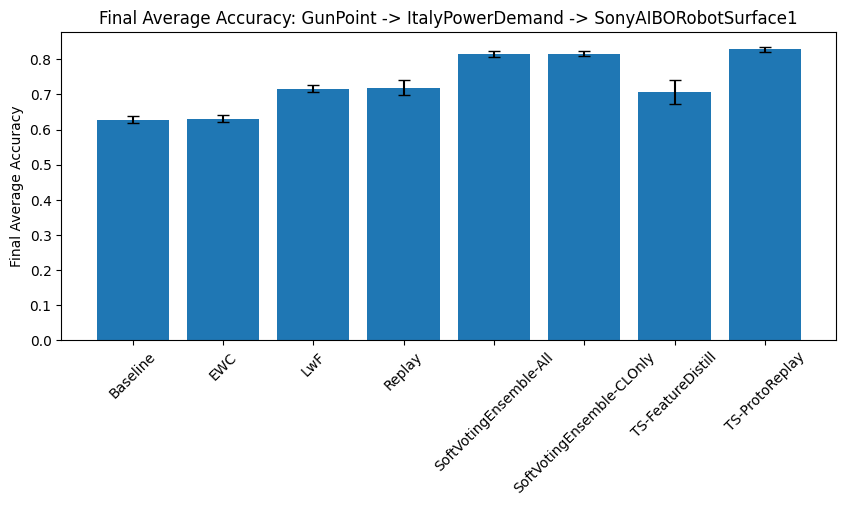

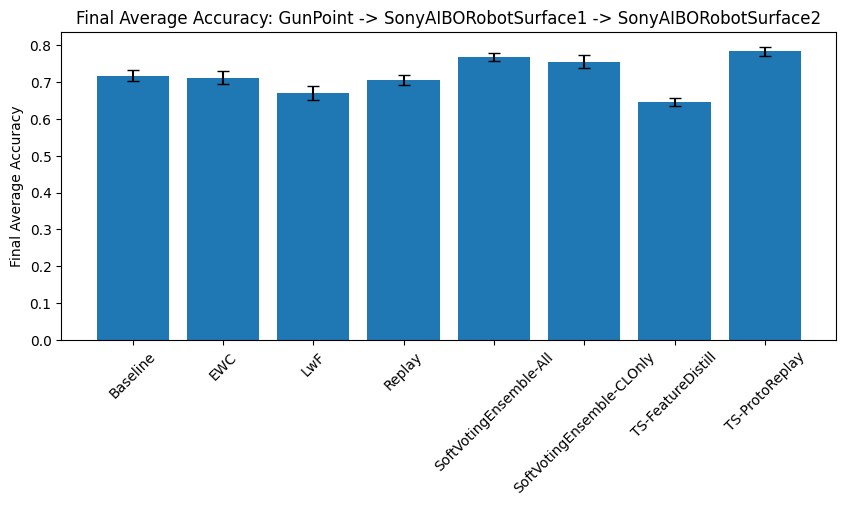

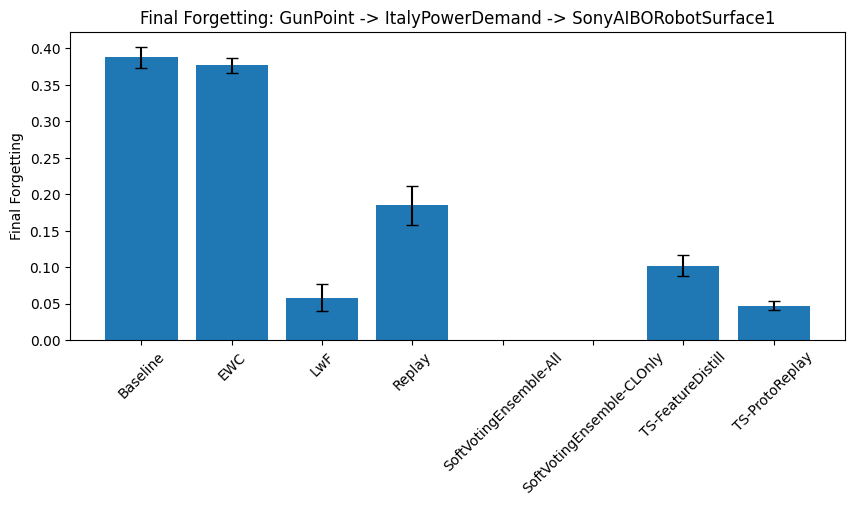

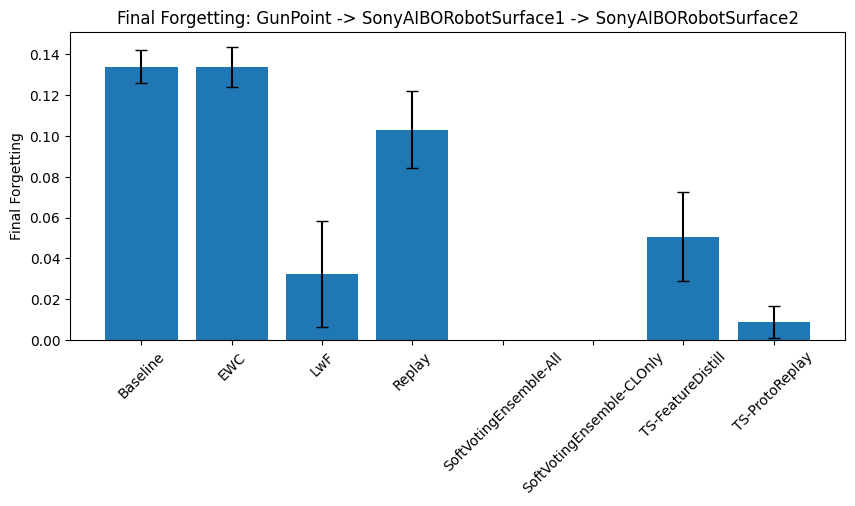

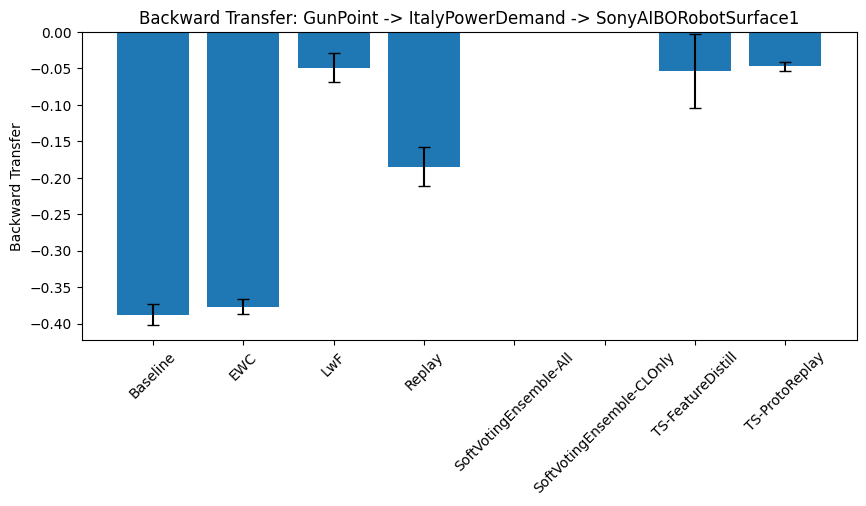

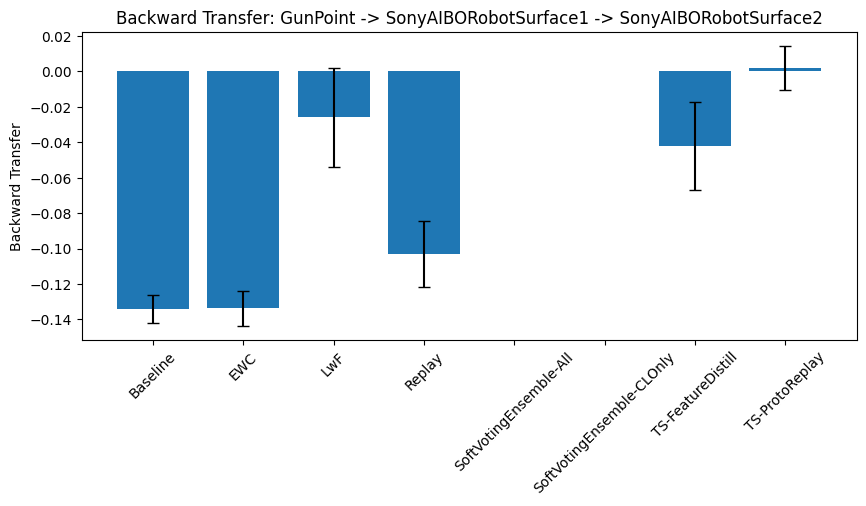

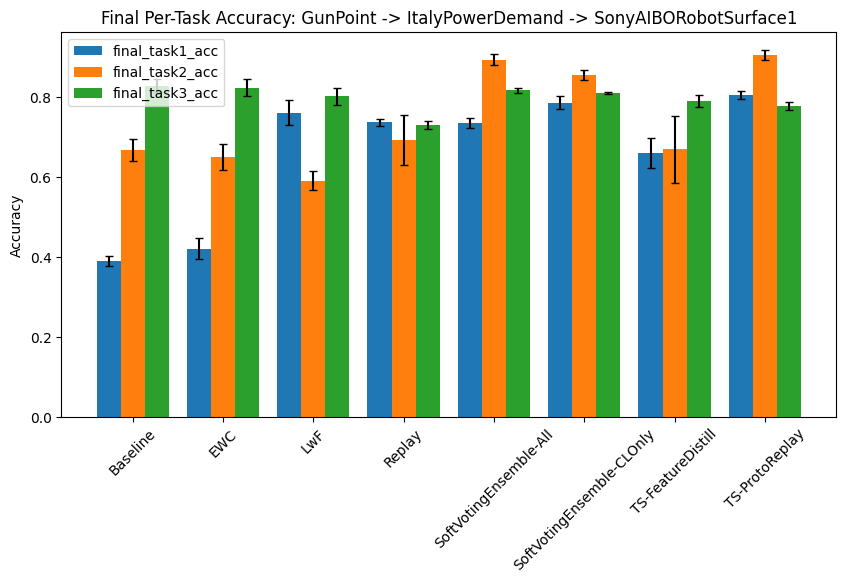

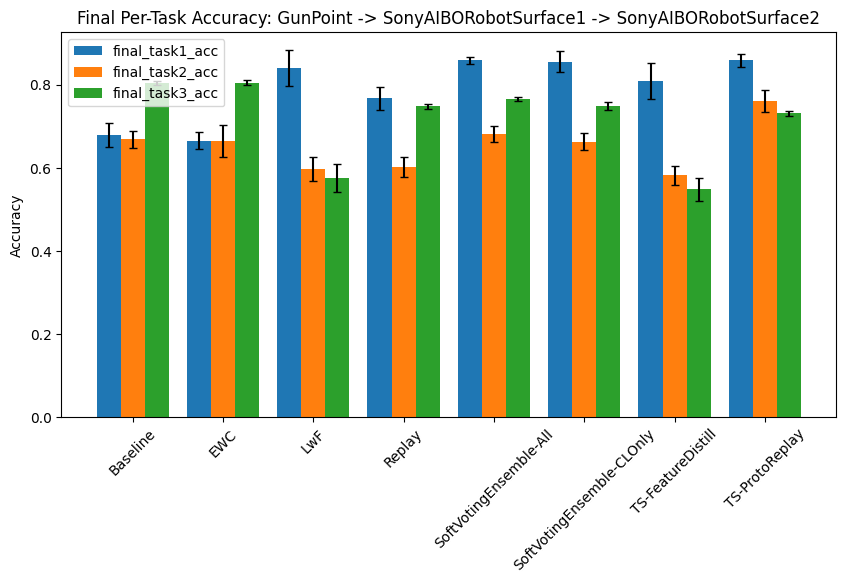

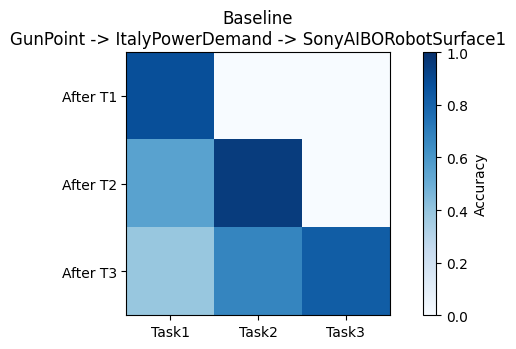

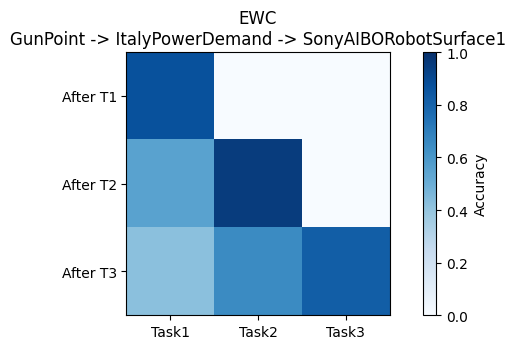

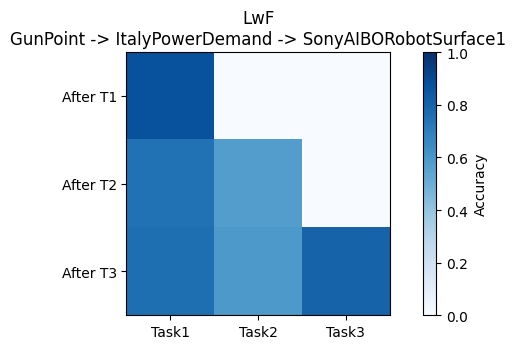

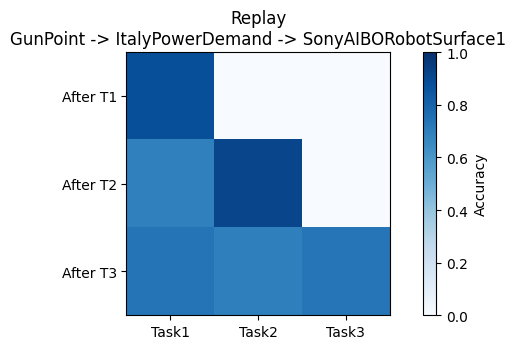

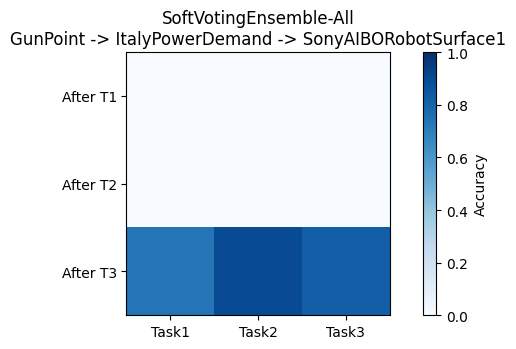

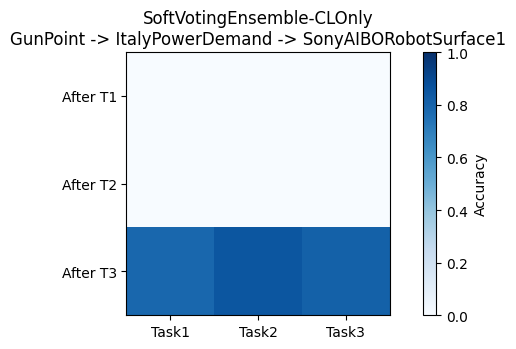

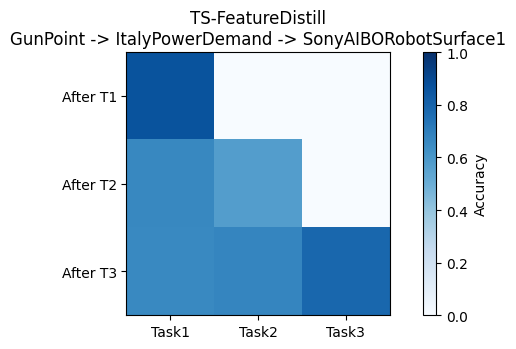

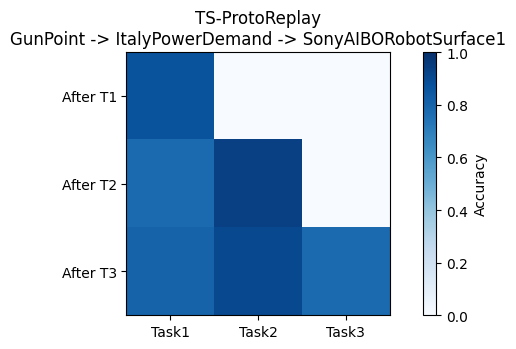

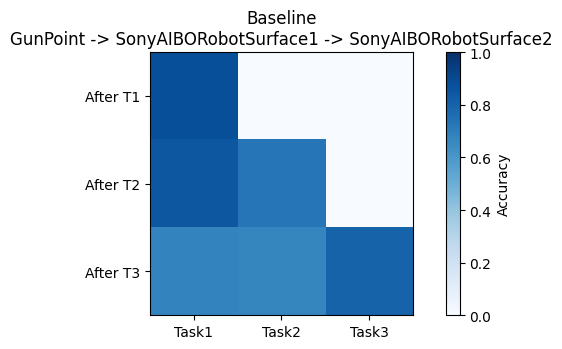

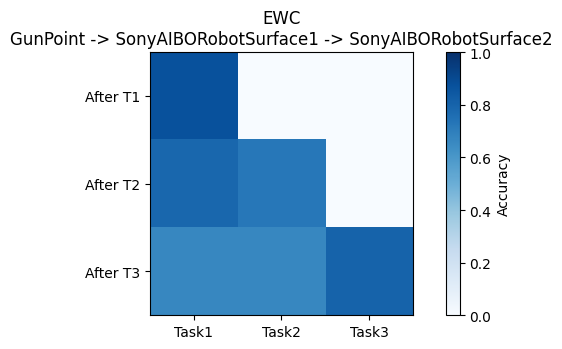

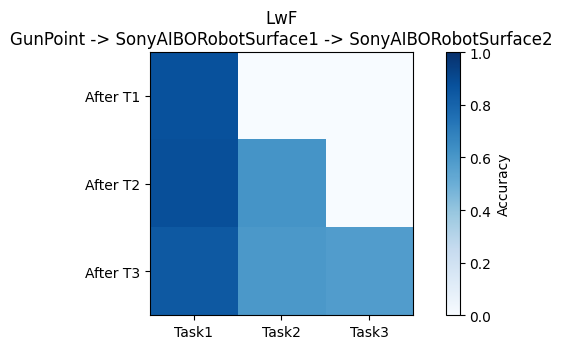

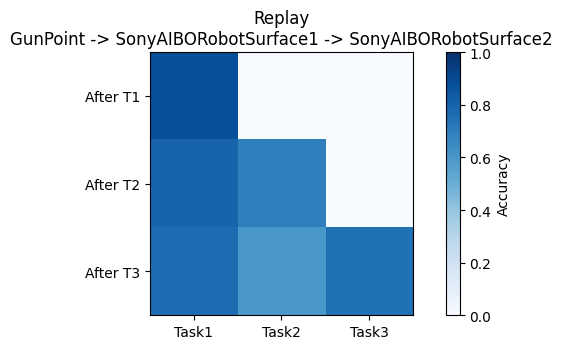

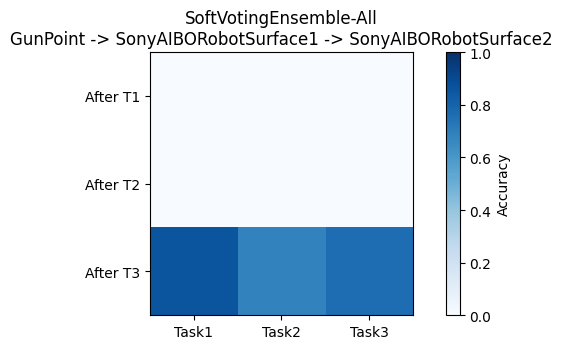

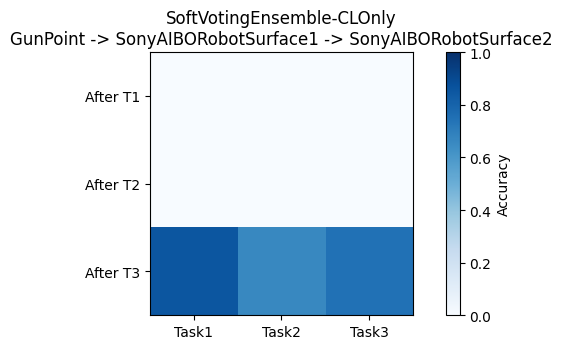

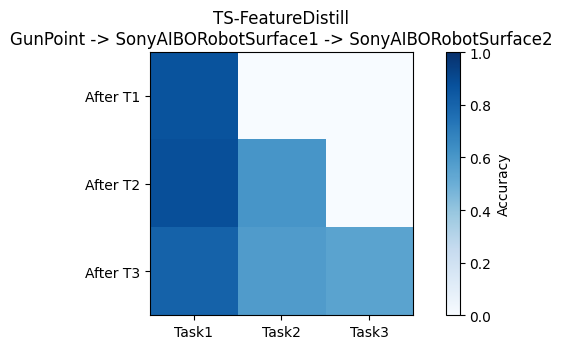

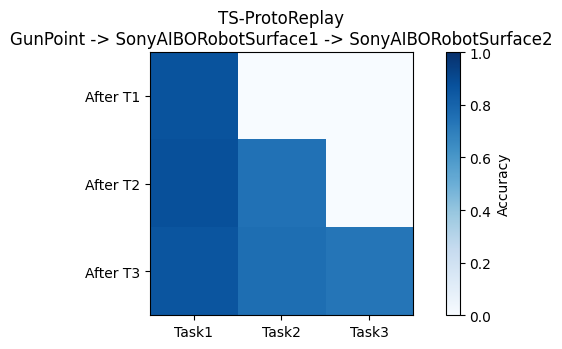

In [ ]:
# ============================================================
# 34) Plot results including ensembles
# ============================================================
plot_sequence_results(agg_df, metric="final_avg_acc_mean")
plot_sequence_results(agg_df, metric="final_forgetting_mean")
plot_sequence_results(agg_df, metric="backward_transfer_mean")

plot_final_task_accuracies(agg_df)
plot_mean_accuracy_matrices(mat_agg)